In [ ]:
from pathlib import Path
from blimpy import Waterfall

directory = Path("/datag/public/A_Sign_in_Space_raw_h5")

patterns = [
    "*.rawspec.0000.h5",
    "*.rawspec.0001.h5",
    "*.rawspec.0002.h5",
]

for pattern in patterns:
    matches = sorted(directory.glob(pattern))
    if not matches:
        continue

    f = matches[0]

    print("=" * 80)
    print(f"Inspecting: {f.name}")

    # Header only
    wf = Waterfall(str(f), load_data=False)

    print(f"foff   : {wf.header['foff']}")
    print(f"tsamp  : {wf.header['tsamp']}")
    print(f"nchans : {wf.header['nchans']}")
    print(f"shape  : {wf.container.selection_shape}")

    # Read only the first 10 frequency channels
    fch1 = wf.header["fch1"]
    foff = wf.header["foff"]

    wf_small = Waterfall(
        str(f),
        f_start=fch1 + 10 * foff,
        f_stop=fch1,
    )

    print("\nTiny data sample:")
    print(wf_small.data)
    print()

In [ ]:
from pathlib import Path

directory = Path("/datag/public/A_Sign_in_Space_raw_h5")

midres_files = sorted(directory.glob("*.rawspec.0002.h5"))

print(f"Found {len(midres_files)} mid-resolution files:\n")

for f in midres_files:
    print(f.name)

In [2]:
from blimpy import Waterfall

wf = Waterfall(
    "/datag/public/A_Sign_in_Space_raw_h5/blc33_guppi_60067_75323_PSR_B0355+54_0012.rawspec.0002.h5",
    load_data=False,
)

print(wf.header["fch1"])
print(wf.header["foff"])
print(wf.header["nchans"])

f_stop = wf.header["fch1"]
f_start = f_stop + wf.header["foff"] * wf.header["nchans"]

print(f_start, f_stop)

8438.96484375
-0.00286102294921875
65536
8251.46484375 8438.96484375


     Top_Hit  Drift_Rate       SNR  Uncorrected_Frequency  \
745      746 -143.769888  3.818304            8407.254619   
348      349  115.015910  3.766401            8407.247605   
315      316  162.939206  3.748207            8407.203285   
767      768   86.261933  3.695627            8407.437848   
778      779 -182.108525  3.685302            8407.223127   
572      573 -306.709095  3.682420            8407.258823   
653      654 -124.600570  3.681518            8407.246046   
711      712  469.648301  3.679463            8407.240643   
254      255  220.447162  3.668661            8407.234787   
639      640 -162.939206  3.644953            8407.223137   
225      226  230.031821  3.642296            8407.239084   
381      382 -450.478983  3.633826            8407.245871   
235      236  239.616480  3.606960            8407.209048   
471      472  412.140346  3.601446            8407.232029   
896      897   57.507955  3.591246            8407.444985   
879      880   67.092614

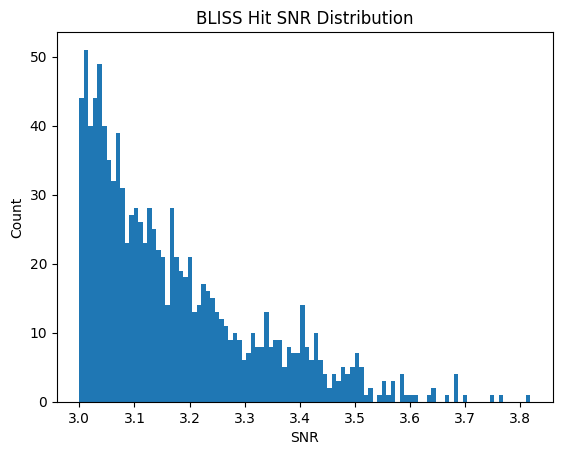

Number of hits: 1106
Maximum SNR: 3.818304
Number above 5 sigma: 0
Number above 10 sigma: 0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/home/wlll2x/turboSETI/PSR_B0355_midres.dat",
    sep=r"\s+",
    comment="#",
    header=None
)

# Remove the unexplained extra column
df = df.iloc[:, :11]

df.columns = [
    "Top_Hit",
    "Drift_Rate",
    "SNR",
    "Uncorrected_Frequency",
    "Corrected_Frequency",
    "Index",
    "freq_start",
    "freq_end",
    "SEFD_freq",
    "Coarse_Channel_Number",
    "Full_number_of_hits"
]

# Strongest candidates
print(df.sort_values("SNR", ascending=False).head(20))

# Summary statistics
print(df["SNR"].describe())

# SNR distribution
plt.hist(df["SNR"], bins=100)
plt.xlabel("SNR")
plt.ylabel("Count")
plt.title("BLISS Hit SNR Distribution")
plt.show()

print("Number of hits:", len(df))
print("Maximum SNR:", df["SNR"].max())
print("Number above 5 sigma:", (df["SNR"] > 5).sum())
print("Number above 10 sigma:", (df["SNR"] > 10).sum())